# TourismSmall Hierarchical Forecasting and Reconciliation

This notebook covers:
1. Exploratory Data Analysis (EDA) of the TourismSmall dataset.
2. Generating base forecasts using `StatsForecast` (AutoARIMA, Naive).
3. Implementing Minimum Trace (MinTrace) reconciliation from scratch.
4. Evaluating and comparing base vs reconciled forecasts.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')

## 1. Load Data

In [7]:
# Define paths (Adjust if running locally/differently)
DATA_DIR = 'data/hierarchical/TourismSmall'

# Load Data
try:
    data = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
    agg_mat = pd.read_csv(os.path.join(DATA_DIR, 'agg_mat.csv'), index_col=0)
except FileNotFoundError:
    # Fallback to absolute path if running from root or different structure
    base_path = r'c:\Users\MarcellNemeth\Documents\BME\phd\codes\HierarchicalTS\notebooks\data\hierarchical\TourismSmall'
    data = pd.read_csv(os.path.join(base_path, 'data.csv'))
    agg_mat = pd.read_csv(os.path.join(base_path, 'agg_mat.csv'), index_col=0)

# Clean up Date column
data.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')

print("Data Shape:", data.shape)
print("Agg Mat Shape:", agg_mat.shape)
data.head()

Data Shape: (36, 89)
Agg Mat Shape: (89, 56)


,total,hol,vfr,bus,oth,nsw-hol,vic-hol,qld-hol,sa-hol,wa-hol,...,qld-oth-city,qld-oth-noncity,sa-oth-city,sa-oth-noncity,wa-oth-city,wa-oth-noncity,tas-oth-city,tas-oth-noncity,nt-oth-city,nt-oth-noncity
date,,,,,,,,,,,,,,,,,,,,,
1998-03-31,84503,45906,26042,9815,2740,17589,10412,9078,3089,3449,...,431,271,244,73,168,37,76,24,35,8
1998-06-30,65312,29347,20676,11823,3466,11027,6025,6310,1935,2454,...,669,170,142,221,170,99,36,61,69,39
1998-09-30,72753,32492,20582,13565,6114,8910,5060,11733,1569,3398,...,270,1164,397,315,380,1166,32,23,150,338
1998-12-31,70880,31813,21613,11478,5976,10658,5481,8109,2270,3561,...,214,535,194,260,410,1139,48,43,172,453
1999-03-31,86893,46793,26947,10027,3126,16152,10958,10047,3023,4287,...,458,557,147,33,162,28,77,60,15,47


## 2. EDA: Plotting Time Series

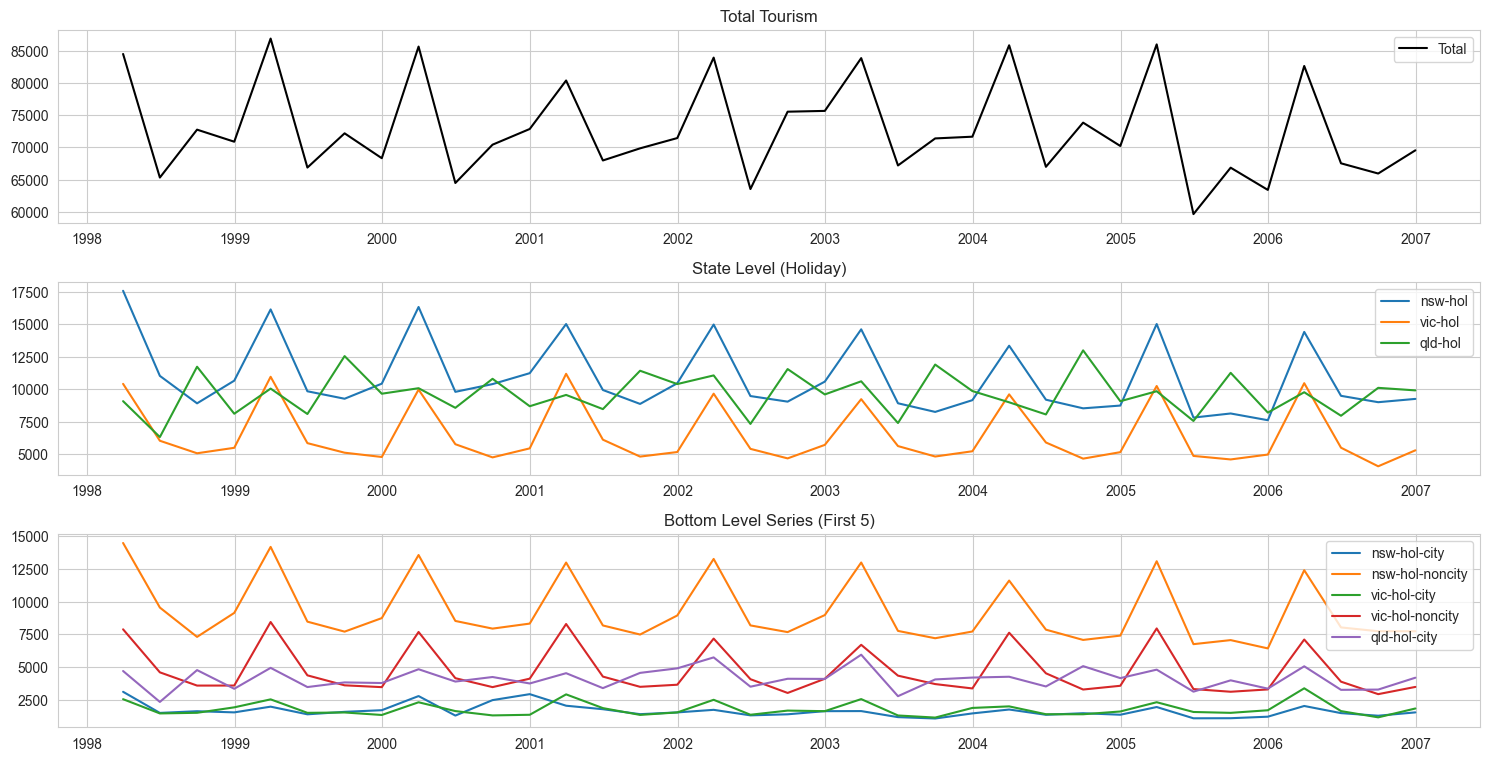

In [8]:
plt.figure(figsize=(15, 10))

# Plot Total
plt.subplot(4, 1, 1)
plt.plot(data.index, data['total'], label='Total', color='black')
plt.title('Total Tourism')
plt.legend()

# Plot a few States (Level 1 typically)
plt.subplot(4, 1, 2)
states = ['nsw-hol', 'vic-hol', 'qld-hol'] # Examples from visual inspection
for c in states:
    if c in data.columns:
        plt.plot(data.index, data[c], label=c)
plt.title('State Level (Holiday)')
plt.legend()

# Plot a few Bottom Level Series
plt.subplot(4, 1, 3)
bottom_cols = agg_mat.columns[:5]
for c in bottom_cols:
    plt.plot(data.index, data[c], label=c)
plt.title('Bottom Level Series (First 5)')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Train/Test Split and Base Forecasts

We will hold out the last 4 quarters (h=4) for testing.

In [9]:
# Prepare data for StatsForecast (long format)
df_long = data.reset_index().melt(id_vars='date', var_name='unique_id', value_name='y')
df_long = df_long.rename(columns={'date': 'ds'})

# Train/Test Split
h = 4
dates = sorted(df_long['ds'].unique())
train_dates = dates[:-h]
test_dates = dates[-h:]

Y_train_df = df_long[df_long['ds'].isin(train_dates)]
Y_test_df = df_long[df_long['ds'].isin(test_dates)]

print(f"Train size: {len(Y_train_df)}, Test size: {len(Y_test_df)}")

Train size: 2848, Test size: 356


In [11]:
# Compute base auto-ARIMA predictions
# Per user instructions: AutoARIMA(season_length=4), Naive()

models = [
    AutoARIMA(season_length=4),
    Naive()
]

fcst = StatsForecast(
    models=models,
    freq='Q-DEC', # Quarterly frequency ending Dec. Data seems quarterly. 'QE' might be deprecated or specific pandas version.
    n_jobs=-1
)

fcst.fit(df=Y_train_df)

# Generate Base Forecasts
Y_hat_df = fcst.forecast(df=Y_train_df, h=h)
Y_hat_df = Y_hat_df.reset_index()

print("Forecasts Generated")
Y_hat_df.head()

Forecasts Generated


c:\Users\MarcellNemeth\Documents\BME\phd\codes\HierarchicalTS\.venv\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Q-DEC' is deprecated and will be removed in a future version, please use 'QE-DEC' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\MarcellNemeth\Documents\BME\phd\codes\HierarchicalTS\.venv\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Q-DEC' is deprecated and will be removed in a future version, please use 'QE-DEC' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


,index,unique_id,ds,AutoARIMA,Naive
0,0,bus,2006-03-31,8918.474609,11547.0
1,1,bus,2006-06-30,9581.921875,11547.0
2,2,bus,2006-09-30,11194.672852,11547.0
3,3,bus,2006-12-31,10678.953125,11547.0
4,4,hol,2006-03-31,42805.343750,26418.0


## 4. MinTrace Reconciliation Implementation

In [12]:
def get_min_trace_predictions(Y_hat_df, Y_train_df, agg_mat, method='AutoARIMA'):
    """
    Reconciles forecasts using MinTrace (Sample Covariance).
    
    Parameters:
    - Y_hat_df: Forecast dataframe containing 'unique_id', 'ds', and model columns
    - Y_train_df: Training dataframe for residual calculation
    - agg_mat: Summing matrix (S matrix)
    - method: Column name of the model to reconcile (e.g., 'AutoARIMA')
    """
    
    # 1. Start by calculating in-sample residuals to estimate W
    # We need fitted values. StatsForecast > 1.0 has predict_in_sample, distinct from fitted?
    # Generally fit() stores fitted values. Let's use predict_in_sample/fitted provided by library.
    # If not available easily, we can re-predict on train data, but let's assume we can use the fitted object.
    
    # Note: In this notebook scope, we already called fit(), so we can use predict_in_sample if accessible.
    # However, to be robust and "from scratch"-ish, let's extract residuals manually if handy method fails,
    # but statsforecast usually has `fcst.predict_in_sample()`
    
    in_sample_preds = fcst.predict_in_sample()
    
    # Merge with actuals to get residuals
    # Ensure alignment
    res_df = in_sample_preds.merge(Y_train_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
    res_df['residual'] = res_df['y'] - res_df[method]
    
    # Pivot residuals to shape (T x N)
    residuals_wide = res_df.pivot(index='ds', columns='unique_id', values='residual')
    
    # Identify ordering from agg_mat
    # agg_mat index = all series names (rows)
    # We need to make sure our vector y_hat is aligned with S rows
    all_series = agg_mat.index.tolist()
    bottom_series = agg_mat.columns.tolist()
    
    # Filter residuals to ensure we have all series cols
    W_data = residuals_wide[all_series]
    
    # Calculate Covariance Matrix W (N x N)
    W = W_data.cov().values
    
    # Identify S matrix
    S = agg_mat.values # Shape (N, M)
    
    # MinTrace Projection Matrix P
    # Formula: P = S (S' W^-1 S)^-1 S' W^-1
    # This gives y_tilde = P y_hat
    
    # Invert W
    # Regularize if necessary (add small epsilon to diag) but usually not needed if T >> N
    # Here T ~ 32, N ~ 89. T < N! cov might be singular or ill-conditioned.
    # Standard MinTrace-Sample requires T > N for estimation. 
    # If T < N, we typically use shrinkage (MinT-Shrink). 
    # Since user asked for implementation "from scratch", implementing full shrinkage is complex.
    # However, let's check if we can use pseudo-inverse or if we should use diagonal W (WLS) if singular.
    # For "from scratch" simple MinTrace, let's try Sample cov first.
    
    try:
        W_inv = np.linalg.inv(W)
    except np.linalg.LinAlgError:
        print("Warning: W is singular, using pseudo-inverse via pinv")
        W_inv = np.linalg.pinv(W)

    # Calculation parts
    # Part A: S' W^-1
    St_Winv = S.T @ W_inv
    
    # Part B: (S' W^-1 S)^-1
    # Inner term
    inner = St_Winv @ S
    inner_inv = np.linalg.inv(inner)
    
    # P matrix
    P = S @ inner_inv @ St_Winv
    
    # Apply reconciliation to forecasts
    # Forecasts wide: (h, N)
    y_hat_wide = Y_hat_df.pivot(index='ds', columns='unique_id', values=method)
    y_hat_wide = y_hat_wide[all_series] # Align columns
    
    # Reconcile: y_tilde = P @ y_hat.T (results in N x h). Transpose back.
    y_tilde = (P @ y_hat_wide.T).T
    
    return y_tilde

# Run Reconciliation for AutoARIMA
Y_tilde_ar = get_min_trace_predictions(Y_hat_df, Y_train_df, agg_mat, method='AutoARIMA')
Y_tilde_naive = get_min_trace_predictions(Y_hat_df, Y_train_df, agg_mat, method='Naive')

print("Reconciliation Complete")

AttributeError: 'StatsForecast' object has no attribute 'predict_in_sample'

## 5. Evaluation

In [ ]:
# Prepare Test Wide for comparison
test_wide = Y_test_df.pivot(index='ds', columns='unique_id', values='y')
test_wide = test_wide[agg_mat.index] # Align

# Helper to calc metrics
def calc_metrics(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} - MSE: {mse:.4f}, MAE: {mae:.4f}")
    return mse, mae

print("--- Evaluation (Aggregated over all series) ---")

# Base
base_ar_wide = Y_hat_df.pivot(index='ds', columns='unique_id', values='AutoARIMA')[agg_mat.index]
calc_metrics(test_wide, base_ar_wide, "Base AutoARIMA")

base_nv_wide = Y_hat_df.pivot(index='ds', columns='unique_id', values='Naive')[agg_mat.index]
calc_metrics(test_wide, base_nv_wide, "Base Naive")

# Reconciled
calc_metrics(test_wide, Y_tilde_ar, "Reconciled AutoARIMA")
calc_metrics(test_wide, Y_tilde_naive, "Reconciled Naive")

## 6. Custom Plotting
Comparison of Base vs Reconciled Forecasts vs Actuals

In [ ]:
def plot_forecast_comparison(series_name, method='AutoARIMA'):
    plt.figure(figsize=(12, 6))
    
    # Plot Train
    train_series = Y_train_df[Y_train_df['unique_id'] == series_name]
    plt.plot(train_series['ds'], train_series['y'], label='Train')
    
    # Plot Test
    test_series = Y_test_df[Y_test_df['unique_id'] == series_name]
    plt.plot(test_series['ds'], test_series['y'], label='Test (Actual)', color='green')
    
    # Plot Base Forecast
    # Extract from Y_hat_df
    base_series = Y_hat_df[Y_hat_df['unique_id'] == series_name]
    plt.plot(base_series['ds'], base_series[method], label=f'Base {method}', linestyle='--', color='red')
    
    # Plot Reconciled Forecast
    # Extract from Y_tilde dataframes (which are indexed by ds)
    if method == 'AutoARIMA':
        rec_series = Y_tilde_ar[series_name]
    else:
        rec_series = Y_tilde_naive[series_name]
        
    plt.plot(rec_series.index, rec_series.values, label=f'Rec {method}', linestyle='-', marker='o', color='purple')
    
    plt.title(f'Forecast Comparison: {series_name}')
    plt.legend()
    plt.show()

# Plot for Total
plot_forecast_comparison('total')

# Plot for a busy series
plot_forecast_comparison('nsw-hol-city')